<a href="https://colab.research.google.com/github/halaBelmo/sms-email-spam/blob/main/sms_spam_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

In [ ]:
df = pd.read_csv('spam.csv', encoding='latin-1')

In [ ]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
df.shape

(5572, 5)

### Data cleaning

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
#drop last 3 columns
df.drop(["Unnamed: 2","Unnamed: 3","Unnamed: 4"], axis = 1, inplace= True)

In [ ]:
#renaming the columns
df.rename({'v1':'target','v2':'Message'},axis=1, inplace=True )

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
encoder = LabelEncoder()

In [ ]:
df['target'] = encoder.fit_transform(df['target'])

In [ ]:
df.head()

,target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
# missing values
df.isnull().sum()

,0
target,0
Message,0


In [ ]:
#duplicate values
df.duplicated().sum()

np.int64(403)

In [ ]:
#remove duplicate
df.drop_duplicates(keep ='first',inplace=True)

In [ ]:
df.duplicated().sum()

np.int64(0)



```
# This is formatted as code
```

### EDA( Exploratory Data Analysis )

In [ ]:
df.head()

,target,Message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
df['target'].value_counts()

,count
target,
0,4516
1,653


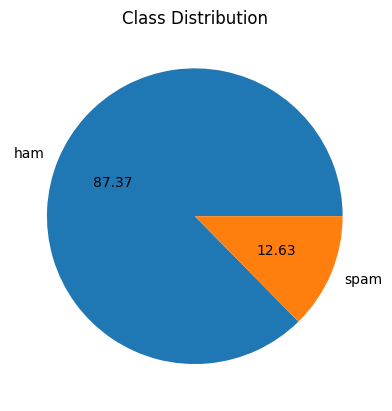

In [ ]:
import matplotlib.pyplot as plt
plt.pie(df['target'].value_counts(),labels=['ham','spam'],autopct= "%0.2f")
plt.title("Class Distribution")
plt.show()

In [ ]:
#The class distribution is imbalanced

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
#number characters
df['n_characters'] = df['Message'].apply(len)
# number of words
df['n_words'] = df['Message'].apply(lambda x: len(nltk.word_tokenize(x)))
# number of sentences
df['n_sentences'] = df['Message'].apply(lambda x: len(nltk.sent_tokenize(x)))



In [ ]:
df.head()

,target,Message,n_characters,n_words,n_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [ ]:
df[df['target'] == 0 ][['n_characters','n_words','n_sentences']].describe()

,n_characters,n_words,n_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [ ]:
df[df['target'] == 1 ][['n_characters','n_words','n_sentences']].describe()

,n_characters,n_words,n_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


In [ ]:
import seaborn as sns

<Axes: xlabel='n_characters', ylabel='Count'>

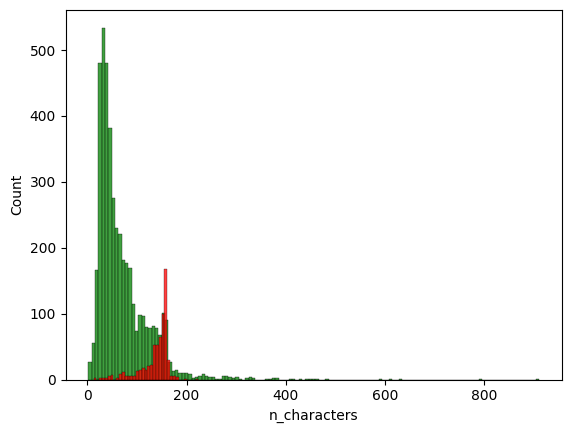

In [ ]:
sns.histplot(df[df['target'] == 0 ]['n_characters']
            ,color='green')
sns.histplot(df[df['target'] == 1 ]['n_characters']
            ,color='red' )

<Axes: xlabel='num_words', ylabel='Count'>

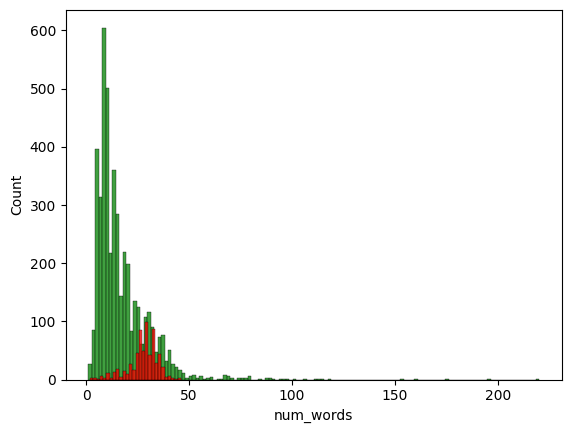

In [ ]:
sns.histplot(df[df['target'] == 0 ]['n_words']
            ,color='green')
sns.histplot(df[df['target'] == 1 ]['n_words']
            ,color='red' )

<Axes: >

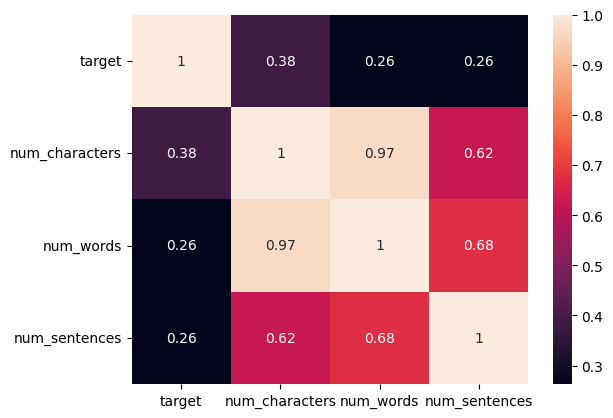

In [ ]:
sns.heatmap(df.select_dtypes(include='number').corr(), annot=True)

### Data Preprocessing


In [ ]:
#lower case
def to_lower(text):
  return text.lower()

In [ ]:
#stemming
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()
nltk.download('stopwords')
def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    txt = []
    for i in text:
        if i.isalnum():
            txt.append(i)

    text = txt[:]
    txt.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            txt.append(i)

    text = txt[:]
    txt.clear()

    for i in text:
        txt.append(ps.stem(i))


    return " ".join(txt)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
df['new_message'] = df['Message'].apply(transform_text)

In [ ]:
df.head()

,target,Message,n_characters,n_words,n_sentences,new_message
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


## Model

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
counV= CountVectorizer()
X= counV.fit_transform(df['new_message']).toarray()
y = df['target'].values
X_train ,X_test ,y_train ,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model = LogisticRegression()
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
#prediction
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test,y_pred)
print('accuracy ',accuracy)

accuracy  0.97678916827853


In [ ]:
print("confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

confusion Matrix:
[[885   4]
 [ 20 125]]


In [ ]:
print("classification Report:")
print(classification_report(y_test, y_pred))

classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       889
           1       0.97      0.86      0.91       145

    accuracy                           0.98      1034
   macro avg       0.97      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034

